In [1]:
import fastf1
import pandas as pd

In [2]:

laps = pd.read_csv("fixrace_f1_session_all_cleaned.csv")

races = pd.read_csv("stint_deg.csv")

In [3]:
laps

,Unnamed: 0,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,...,IsAccurate,Year,Round,Session,fuel_kg,fuel_adjustment,fuel_effect,lap_time_s,fuel_delta_to_55,lap_time_fuel_std_55kg
0,0,0 days 01:04:15.340000,VER,1,0 days 00:01:40.236000,1.0,1.0,NaN,NaN,NaN,...,False,2022,1,Race,110.000000,3.300000,0.03,100.236,1.650000,98.586000
1,1,0 days 01:05:53.220000,VER,1,0 days 00:01:37.880000,2.0,1.0,NaN,NaN,0 days 00:00:31.285000,...,True,2022,1,Race,108.049107,3.241473,0.03,97.880,1.591473,96.288527
2,2,0 days 01:07:31.577000,VER,1,0 days 00:01:38.357000,3.0,1.0,NaN,NaN,0 days 00:00:31.499000,...,True,2022,1,Race,106.098214,3.182946,0.03,98.357,1.532946,96.824054
3,3,0 days 01:09:10.143000,VER,1,0 days 00:01:38.566000,4.0,1.0,NaN,NaN,0 days 00:00:31.342000,...,True,2022,1,Race,104.147321,3.124420,0.03,98.566,1.474420,97.091580
4,4,0 days 01:10:49.020000,VER,1,0 days 00:01:38.877000,5.0,1.0,NaN,NaN,0 days 00:00:31.498000,...,True,2022,1,Race,102.196429,3.065893,0.03,98.877,1.415893,97.461107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103416,103416,0 days 02:13:00.598000,PIA,81,0 days 00:01:34.588000,46.0,2.0,NaN,NaN,0 days 00:00:26.951000,...,True,2025,22,Race,9.668367,0.193367,0.02,94.588,-0.906633,95.494633
103417,103417,0 days 02:14:34.684000,PIA,81,0 days 00:01:34.086000,47.0,2.0,NaN,NaN,0 days 00:00:26.763000,...,True,2025,22,Race,7.438776,0.148776,0.02,94.086,-0.951224,95.037224
103418,103418,0 days 02:16:08.849000,PIA,81,0 days 00:01:34.165000,48.0,2.0,NaN,NaN,0 days 00:00:26.769000,...,True,2025,22,Race,5.209184,0.104184,0.02,94.165,-0.995816,95.160816
103419,103419,0 days 02:17:43.315000,PIA,81,0 days 00:01:34.466000,49.0,2.0,NaN,NaN,0 days 00:00:26.922000,...,True,2025,22,Race,2.979592,0.059592,0.02,94.466,-1.040408,95.506408


In [4]:
print(laps.FreshTyre.tail(10))

103411    True
103412    True
103413    True
103414    True
103415    True
103416    True
103417    True
103418    True
103419    True
103420    True
Name: FreshTyre, dtype: bool


In [5]:
cols_to_drop = [
    "Sector1SessionTime",
    "Sector2SessionTime",
    "Sector3SessionTime",
    "LapStartDate",
    "Deleted",
    "DeletedReason",
    "PitOutTime",
    "PitInTime",
    "LapStartTime",
    "IsAccurate",
    "TrackStatus",
    "Unnamed: 0",
    "Sector1Time",
    "Sector2Time",
    "Sector3Time",
    "IsPersonalBest",
    "LapTime"
]
laps = laps.drop(columns=cols_to_drop, errors='ignore')

In [6]:
laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapNumber', 'Stint', 'SpeedI1',
       'SpeedI2', 'SpeedFL', 'SpeedST', 'Compound', 'TyreLife', 'FreshTyre',
       'Team', 'Position', 'FastF1Generated', 'Year', 'Round', 'Session',
       'fuel_kg', 'fuel_adjustment', 'fuel_effect', 'lap_time_s',
       'fuel_delta_to_55', 'lap_time_fuel_std_55kg'],
      dtype='object')

In [7]:
nan_rows = laps[laps["lap_time_fuel_std_55kg"].isna()]

laps = laps[laps['lap_time_s'] <= 400]
nan_rows.describe()

,DriverNumber,LapNumber,Stint,SpeedI1,SpeedI2,SpeedFL,SpeedST,TyreLife,Position,Year,Round,fuel_kg,fuel_adjustment,fuel_effect,lap_time_s,fuel_delta_to_55,lap_time_fuel_std_55kg
count,1407.000000,1407.000000,1404.000000,1238.000000,1239.000000,1034.000000,1139.000000,1392.000000,1248.000000,1407.000000,1407.000000,1407.000000,1407.000000,1407.000000,0.0,1407.000000,0.0
mean,27.618337,14.526652,1.812678,201.405493,175.041969,224.724371,200.447761,6.099138,9.301282,2023.351812,12.073205,84.441845,2.375711,0.028998,NaN,0.780828,NaN
std,23.389279,18.572811,1.174004,68.388379,62.374901,78.368062,77.990264,7.398405,5.494527,1.065044,6.760665,33.735177,1.045108,0.006751,NaN,1.058691,NaN
min,1.000000,1.000000,1.000000,38.000000,33.000000,2.000000,54.000000,1.000000,1.000000,2022.000000,1.000000,0.750000,0.015000,0.020000,NaN,-2.170000,NaN
25%,10.000000,1.000000,1.000000,147.000000,125.000000,200.000000,135.500000,1.000000,5.000000,2022.000000,5.000000,62.083333,1.838276,0.020000,NaN,0.243137,NaN
50%,21.000000,4.000000,1.000000,201.000000,174.000000,243.000000,204.000000,4.000000,9.000000,2023.000000,12.000000,102.196429,2.388413,0.030000,NaN,1.057981,NaN
75%,44.000000,26.000000,2.000000,258.000000,226.000000,277.750000,264.000000,7.000000,14.000000,2024.000000,18.000000,110.000000,3.300000,0.030000,NaN,1.650000,NaN
max,87.000000,71.000000,8.000000,339.000000,313.000000,329.000000,336.000000,56.000000,20.000000,2025.000000,24.000000,110.000000,4.400000,0.040000,NaN,2.200000,NaN


In [8]:
# laps['TyreLife'] = laps['TyreLife'].fillna(0)
laps = laps.dropna(subset=['lap_time_fuel_std_55kg'])
laps = laps.dropna(subset=['TyreLife'])


In [12]:
# weather[weather["Rainfall"] == True]

In [125]:
laps_round1_2022 = laps[(laps['Year'] == 2022) & (laps['Round'] ==2)]
# laps_round1_2022 = laps
median_lap = laps_round1_2022['lap_time_fuel_std_55kg'].median()
laps_round1_2022 = laps_round1_2022[laps['lap_time_fuel_std_55kg'] <= 1.03* median_lap]

C:\Users\onehi\AppData\Local\Temp\ipykernel_39740\359016420.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  laps_round1_2022 = laps_round1_2022[laps['lap_time_fuel_std_55kg'] <= 1.03* median_lap]


In [126]:
# Normalization not really needed for this
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# standardized = scaler.fit_transform(
#     laps_round1_2022[['TyreLife', 'lap_time_fuel_std_55kg']]
# )

# laps_round1_2022['TyreLife_std'] = standardized[:, 0]
# laps_round1_2022['LapTime_std'] = standardized[:, 1]


In [127]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = laps_round1_2022["TyreLife"].values.reshape(-1, 1)
y = laps_round1_2022["lap_time_fuel_std_55kg"].values

model_tyre = LinearRegression()
model_tyre.fit(X, y)

print("TyreLife → Lap Time")
print("Slope:", model_tyre.coef_[0])
print("Intercept:", model_tyre.intercept_)
print("R²:", model_tyre.score(X, y))

TyreLife → Lap Time
Slope: -0.015498133587455047
Intercept: 95.44451686259607
R²: 0.015337672602312113


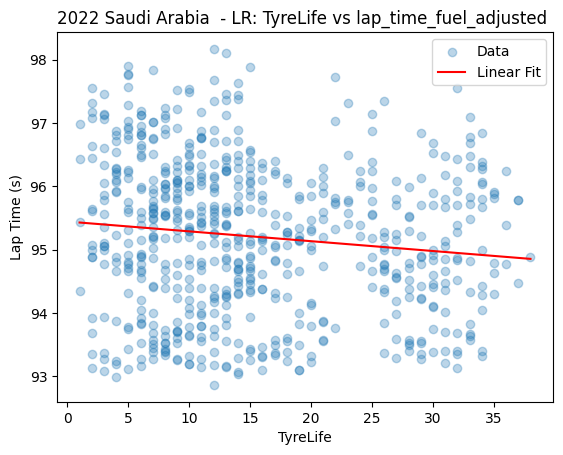

In [128]:
import matplotlib.pyplot as plt

plt.scatter(laps_round1_2022['TyreLife'], laps_round1_2022['lap_time_fuel_std_55kg'], alpha=0.3, label='Data')

X_line = np.linspace(laps_round1_2022['TyreLife'].min(), laps_round1_2022['TyreLife'].max(), 100).reshape(-1, 1)
y_line = model_tyre.predict(X_line)

plt.plot(X_line, y_line, color='red', label='Linear Fit')

plt.xlabel('TyreLife')
plt.ylabel('Lap Time (s)')
plt.title('2022 Saudi Arabia  - LR: TyreLife vs lap_time_fuel_adjusted ')
plt.legend()
plt.show()

In [87]:
laps_round1_2022 = laps[(laps['Year'] == 2022) & (laps['Round'] == 7)]

In [18]:
laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapNumber', 'Stint', 'SpeedI1',
       'SpeedI2', 'SpeedFL', 'SpeedST', 'Compound', 'TyreLife', 'FreshTyre',
       'Team', 'Position', 'FastF1Generated', 'Year', 'Round', 'Session',
       'fuel_kg', 'fuel_adjustment', 'fuel_effect', 'lap_time_s',
       'fuel_delta_to_55', 'lap_time_fuel_std_55kg'],
      dtype='object')

In [19]:
unique_sessions = (
    laps[['Year', 'Round', 'Session']]
    .drop_duplicates()
    .sort_values(['Year', 'Round'])
)
print(unique_sessions)

        Year  Round Session
0       2022      1    Race
1049    2022      2    Race
1801    2022      3    Race
2773    2022      4  Sprint
3134    2022      4    Race
...      ...    ...     ...
98550   2025     19    Race
99617   2025     20    Race
100881  2025     21  Sprint
101324  2025     21    Race
102536  2025     22    Race

[110 rows x 3 columns]


In [20]:
ses = fastf1.get_session(2025, 1, "Race")
# ses.weather_data

req         WARNING 	DEFAULT CACHE ENABLED! (8.15 GB) C:\Users\onehi\AppData\Local\Temp\fastf1


In [22]:
# ses.weather_data

In [ ]:
import time
weather_dfs = []  # store weather data for merging later
fastf1.set_log_level("ERROR")
for _, row in unique_sessions.iterrows():
    time.sleep(0.5)
    
    year = int(row['Year'])
    rnd = int(row['Round'])
    session_name = row['Session']

    print(f"Loading {year} Round {rnd} {session_name}...")

    try:
        session = fastf1.get_session(year, rnd, session_name)
    except ValueError as e:
        print(f"Skipping {year} Round {rnd} {session_name}: {e}")
        continue
    session.load(weather=True)

    if not hasattr(session, "_weather_data") or session._weather_data is None:
        print(f"Weather data not available for {year} R{rnd} {session_name}")
        continue

    weather = session.weather_data 
    weather = weather.reset_index().rename(columns={'Time': 'weather_time'})
    weather['Year'] = year
    weather['Round'] = rnd
    weather['Session'] = session_name

    weather_dfs.append(weather)

Loading 2022 Round 1 Race...
Loading 2022 Round 2 Race...
Loading 2022 Round 3 Race...
Loading 2022 Round 4 Sprint...
Loading 2022 Round 4 Race...
Loading 2022 Round 5 Race...
Loading 2022 Round 6 Race...
Loading 2022 Round 7 Race...
Loading 2022 Round 8 Race...
Loading 2022 Round 9 Race...
Loading 2022 Round 10 Race...
Loading 2022 Round 11 Sprint...
Loading 2022 Round 11 Race...
Loading 2022 Round 12 Race...
Loading 2022 Round 13 Race...
Loading 2022 Round 14 Race...
Loading 2022 Round 15 Race...
Loading 2022 Round 16 Race...
Loading 2022 Round 17 Race...
Loading 2022 Round 18 Race...
Loading 2022 Round 19 Race...
Loading 2022 Round 20 Race...
Loading 2022 Round 21 Sprint...
Loading 2022 Round 21 Race...
Loading 2022 Round 22 Race...
Loading 2023 Round 1 Race...
Loading 2023 Round 2 Race...
Loading 2023 Round 3 Race...
Loading 2023 Round 4 Sprint...
Loading 2023 Round 4 Race...
Loading 2023 Round 5 Race...
Loading 2023 Round 6 Race...
Loading 2023 Round 7 Race...
Loading 2023 Round 8

In [ ]:
weather_all = pd.concat(weather_dfs, ignore_index=True)


,index,weather_time,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed,Year,Round,Session
0,0,0 days 00:01:03.204000,25.6,17.0,1010.2,False,32.3,346,0.5,2022,1,Race
1,1,0 days 00:02:03.202000,25.7,17.0,1010.2,False,32.3,347,0.6,2022,1,Race
2,2,0 days 00:03:03.205000,25.7,17.0,1010.0,False,32.2,359,0.4,2022,1,Race
3,3,0 days 00:04:03.220000,25.7,17.0,1010.2,False,32.2,8,0.4,2022,1,Race
4,4,0 days 00:05:03.218000,25.6,17.0,1010.0,False,32.1,16,0.5,2022,1,Race
...,...,...,...,...,...,...,...,...,...,...,...,...
12627,173,0 days 02:53:09.006000,16.1,72.0,1010.4,False,18.7,170,1.4,2025,1,Race
12628,174,0 days 02:54:09.025000,16.2,72.0,1010.6,False,18.7,216,2.4,2025,1,Race
12629,175,0 days 02:55:09.010000,16.2,71.0,1010.4,False,18.7,215,2.8,2025,1,Race
12630,176,0 days 02:56:09.020000,16.2,71.0,1010.4,False,18.7,215,2.8,2025,1,Race


In [ ]:
weather_all.to_csv("weather 2022-2024.csv", index=False)

In [32]:
laps = pd.read_csv('model_data.csv') 

In [33]:
laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapNumber', 'Stint', 'Compound',
       'TyreLife', 'FreshTyre', 'Team', 'Position', 'Year', 'Round', 'Session',
       'fuel_kg', 'fuel_adjustment', 'fuel_effect', 'lap_time_s',
       'fuel_delta_to_55', 'lap_time_fuel_std_55kg', 'median_lap_time_x',
       'percent_lap_time', 'median_lap_time_y', 'lap_time_std_z',
       'TyreLife_z'],
      dtype='object')

In [34]:
session = fastf1.get_session(2022, 1, "Race")
session.load()

weather = session.weather_data
print(weather.columns)

logger      WARNING 	Failed to load schedule from FastF1 backend!
req            INFO 	Using cached data for season_schedule
core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 16 completed the race distance 00:00.050000 before the recorded end of the session.
c

Index(['Time', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp',
       'WindDirection', 'WindSpeed'],
      dtype='object')


In [35]:
laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapNumber', 'Stint', 'Compound',
       'TyreLife', 'FreshTyre', 'Team', 'Position', 'Year', 'Round', 'Session',
       'fuel_kg', 'fuel_adjustment', 'fuel_effect', 'lap_time_s',
       'fuel_delta_to_55', 'lap_time_fuel_std_55kg', 'median_lap_time_x',
       'percent_lap_time', 'median_lap_time_y', 'lap_time_std_z',
       'TyreLife_z'],
      dtype='object')

In [36]:
median_per_group = (
    laps.groupby(["Year", "Round", "Session"])["lap_time_fuel_std_55kg"]
      .median()
      .rename("median_lap_time")
)
median_per_group

Year  Round  Session
2022  1      Race       99.325804
      2      Race       95.364776
      3      Race       84.649000
      4      Race       82.502008
             Sprint     80.133355
                          ...    
2025  19     Sprint     97.917318
      20     Race       82.710714
      21     Race       74.963857
             Sprint     72.928607
      22     Race       96.259347
Name: median_lap_time, Length: 107, dtype: float64

In [130]:
laps = laps.merge(median_per_group, on=["Year", "Round", "Session"])

MergeError: Passing 'suffixes' which cause duplicate columns {'median_lap_time_x'} is not allowed.

In [ ]:
laps["percent_lap_time"] = (
    laps["lap_time_fuel_std_55kg"] / laps["median_lap_time"]
)

In [131]:
laps.describe

<bound method NDFrame.describe of                          Time Driver  DriverNumber  LapNumber  Stint Compound  \
0      0 days 01:04:15.340000    VER             1        1.0    1.0       C3   
1      0 days 01:05:53.220000    VER             1        2.0    1.0       C3   
2      0 days 01:07:31.577000    VER             1        3.0    1.0       C3   
3      0 days 01:09:10.143000    VER             1        4.0    1.0       C3   
4      0 days 01:10:49.020000    VER             1        5.0    1.0       C3   
...                       ...    ...           ...        ...    ...      ...   
90157  0 days 02:13:00.598000    PIA            81       46.0    2.0       C3   
90158  0 days 02:14:34.684000    PIA            81       47.0    2.0       C3   
90159  0 days 02:16:08.849000    PIA            81       48.0    2.0       C3   
90160  0 days 02:17:43.315000    PIA            81       49.0    2.0       C3   
90161  0 days 02:19:17.976000    PIA            81       50.0    2.0       

In [132]:
f_laps = laps[(laps['percent_lap_time'] >= 0.9) & 
              (laps['percent_lap_time'] <= 1.075)]

In [133]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = f_laps["TyreLife"].values.reshape(-1, 1)
y = f_laps["percent_lap_time"].values

model_tyre = LinearRegression()
model_tyre.fit(X, y)

print("TyreLife → Lap Time")
print("Slope:", model_tyre.coef_[0])
print("Intercept:", model_tyre.intercept_)
print("R²:", model_tyre.score(X, y))

TyreLife → Lap Time
Slope: 0.00036913232319475524
Intercept: 0.9954928416887151
R²: 0.06129563152293949


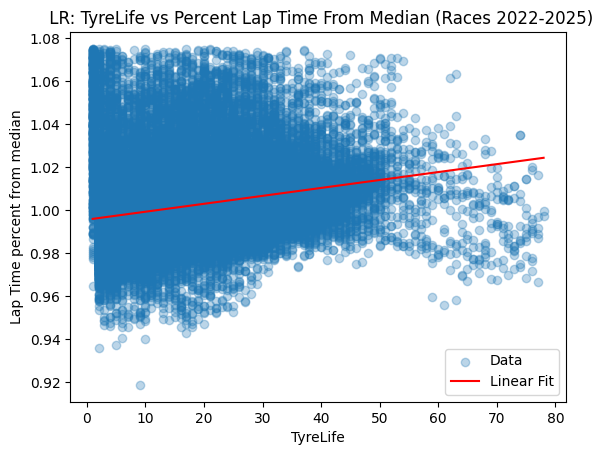

In [135]:


plt.scatter(f_laps['TyreLife'], f_laps['percent_lap_time'], alpha=0.3, label='Data')

X_line = np.linspace(f_laps['TyreLife'].min(), f_laps['TyreLife'].max(), 100).reshape(-1, 1)
y_line = model_tyre.predict(X_line)

plt.plot(X_line, y_line, color='red', label='Linear Fit')

plt.xlabel('TyreLife')
plt.ylabel('Lap Time percent from median')
plt.title(' LR: TyreLife vs Percent Lap Time From Median (Races 2022-2025)')
plt.legend()
plt.show()

In [136]:
laps['lap_time_std_z'] = laps.groupby(['Year','Round','Session'])['lap_time_fuel_std_55kg'].transform(lambda x: (x - x.mean())/x.std())


In [143]:
# f_laps = laps[laps['percent_lap_time'] <= 1.10]
laps['TyreLife_z'] = (
    (laps['TyreLife'] - laps['TyreLife'].mean()) /
    laps['TyreLife'].std()
)
dry_laps = laps[~laps["Compound"].isin(["W", "I"])]
z_laps = dry_laps[
    (dry_laps['lap_time_std_z'] <= 2.2) &
    (dry_laps['lap_time_std_z'] >= -2.2)
]



In [144]:
laps

,Time,Driver,DriverNumber,LapNumber,Stint,Compound,TyreLife,FreshTyre,Team,Position,...,fuel_effect,lap_time_s,fuel_delta_to_55,lap_time_fuel_std_55kg,median_lap_time_x,percent_lap_time,median_lap_time_y,lap_time_std_z,TyreLife_z,median_lap_time
0,0 days 01:04:15.340000,VER,1,1.0,1.0,C3,4.0,False,Red Bull Racing,2.0,...,0.03,100.236,1.650000,98.586000,99.485527,0.992552,99.485527,-0.522553,-1.103856,99.325804
1,0 days 01:05:53.220000,VER,1,2.0,1.0,C3,5.0,False,Red Bull Racing,2.0,...,0.03,97.880,1.591473,96.288527,99.485527,0.969421,99.485527,-1.665573,-1.004440,99.325804
2,0 days 01:07:31.577000,VER,1,3.0,1.0,C3,6.0,False,Red Bull Racing,2.0,...,0.03,98.357,1.532946,96.824054,99.485527,0.974813,99.485527,-1.399142,-0.905023,99.325804
3,0 days 01:09:10.143000,VER,1,4.0,1.0,C3,7.0,False,Red Bull Racing,2.0,...,0.03,98.566,1.474420,97.091580,99.485527,0.977506,99.485527,-1.266044,-0.805607,99.325804
4,0 days 01:10:49.020000,VER,1,5.0,1.0,C3,8.0,False,Red Bull Racing,2.0,...,0.03,98.877,1.415893,97.461107,99.485527,0.981226,99.485527,-1.082201,-0.706190,99.325804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90157,0 days 02:13:00.598000,PIA,81,46.0,2.0,C3,25.0,True,McLaren,5.0,...,0.02,94.588,-0.906633,95.494633,96.340571,0.992056,96.340571,-0.513413,0.983891,96.259347
90158,0 days 02:14:34.684000,PIA,81,47.0,2.0,C3,26.0,True,McLaren,5.0,...,0.02,94.086,-0.951224,95.037224,96.340571,0.987304,96.340571,-0.674771,1.083307,96.259347
90159,0 days 02:16:08.849000,PIA,81,48.0,2.0,C3,27.0,True,McLaren,5.0,...,0.02,94.165,-0.995816,95.160816,96.340571,0.988588,96.340571,-0.631172,1.182724,96.259347
90160,0 days 02:17:43.315000,PIA,81,49.0,2.0,C3,28.0,True,McLaren,5.0,...,0.02,94.466,-1.040408,95.506408,96.340571,0.992178,96.340571,-0.509259,1.282141,96.259347


TyreLife_z → Lap Time
Slope: 0.18723052224114375
Intercept: -0.14182787344797285
R²: 0.08108597978935472


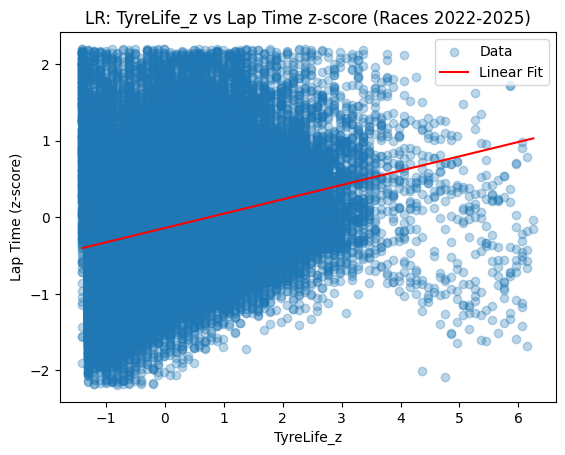

In [145]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

X = z_laps["TyreLife_z"].values.reshape(-1, 1)
y = z_laps["lap_time_std_z"].values

model_tyre = LinearRegression()
model_tyre.fit(X, y)

print("TyreLife_z → Lap Time")
print("Slope:", model_tyre.coef_[0])
print("Intercept:", model_tyre.intercept_)
print("R²:", model_tyre.score(X, y))

plt.scatter(z_laps['TyreLife_z'], z_laps['lap_time_std_z'], alpha=0.3, label='Data')

X_line = np.linspace(z_laps['TyreLife_z'].min(), z_laps['TyreLife_z'].max(), 100).reshape(-1, 1)
y_line = model_tyre.predict(X_line)

plt.plot(X_line, y_line, color='red', label='Linear Fit')

plt.xlabel('TyreLife_z')
plt.ylabel('Lap Time (z-score)')
plt.title('LR: TyreLife_z vs Lap Time z-score (Races 2022-2025)')
plt.legend()
plt.show()

In [67]:
laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapNumber', 'Stint', 'Compound',
       'TyreLife', 'FreshTyre', 'Team', 'Position', 'Year', 'Round', 'Session',
       'fuel_kg', 'fuel_adjustment', 'fuel_effect', 'lap_time_s',
       'fuel_delta_to_55', 'lap_time_fuel_std_55kg', 'median_lap_time_x',
       'percent_lap_time', 'median_lap_time_y', 'lap_time_std_z',
       'TyreLife_z'],
      dtype='object')

In [ ]:
cols_to_drop = [
    "SpeedI1",
    "SpeedI2",
    "SpeedFL",
    "SpeedST",
    "FastF1Generated"
]
laps = laps.drop(columns=cols_to_drop, errors='ignore')
laps.drop

<bound method DataFrame.drop of                           Time Driver  DriverNumber  LapNumber  Stint  \
0       0 days 01:04:15.340000    VER             1        1.0    1.0   
1       0 days 01:05:53.220000    VER             1        2.0    1.0   
2       0 days 01:07:31.577000    VER             1        3.0    1.0   
3       0 days 01:09:10.143000    VER             1        4.0    1.0   
4       0 days 01:10:49.020000    VER             1        5.0    1.0   
...                        ...    ...           ...        ...    ...   
100942  0 days 02:13:00.598000    PIA            81       46.0    2.0   
100943  0 days 02:14:34.684000    PIA            81       47.0    2.0   
100944  0 days 02:16:08.849000    PIA            81       48.0    2.0   
100945  0 days 02:17:43.315000    PIA            81       49.0    2.0   
100946  0 days 02:19:17.976000    PIA            81       50.0    2.0   

       Compound  TyreLife  FreshTyre             Team  Position  ...  \
0            C3    

In [61]:
wet_laps = laps[laps["Compound"].isin(["W", "I"])]
wet_laps

,Time,Driver,DriverNumber,LapNumber,Stint,Compound,TyreLife,FreshTyre,Team,Position,...,fuel_kg,fuel_adjustment,fuel_effect,lap_time_s,fuel_delta_to_55,lap_time_fuel_std_55kg,median_lap_time_x,percent_lap_time,median_lap_time_y,lap_time_std_z
3086,0 days 01:03:54.765000,VER,1,1.0,1.0,I,1.0,True,Red Bull Racing,1.0,...,110.000000,3.300000,0.03,111.307,1.650000,109.657000,82.979694,1.321492,82.979694,2.178946
3087,0 days 01:11:04.687000,VER,1,4.0,1.0,I,4.0,True,Red Bull Racing,1.0,...,104.713710,3.141411,0.03,147.427,1.491411,145.935589,82.979694,1.758690,82.979694,5.722523
3088,0 days 01:12:36.137000,VER,1,5.0,1.0,I,5.0,True,Red Bull Racing,1.0,...,102.951613,3.088548,0.03,91.450,1.438548,90.011452,82.979694,1.084741,82.979694,0.260032
3089,0 days 01:14:06.581000,VER,1,6.0,1.0,I,6.0,True,Red Bull Racing,1.0,...,101.189516,3.035685,0.03,90.444,1.385685,89.058315,82.979694,1.073254,82.979694,0.166932
3090,0 days 01:15:36.700000,VER,1,7.0,1.0,I,7.0,True,Red Bull Racing,1.0,...,99.427419,2.982823,0.03,90.119,1.332823,88.786177,82.979694,1.069975,82.979694,0.140351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90174,0 days 02:36:41.213000,HAD,6,9.0,1.0,I,9.0,True,Racing Bulls,8.0,...,89.674419,1.793488,0.02,123.822,0.693488,123.128512,108.192605,1.138049,108.257919,0.547691
90175,0 days 02:38:45.949000,HAD,6,10.0,1.0,I,10.0,True,Racing Bulls,8.0,...,87.133721,1.742674,0.02,124.736,0.642674,124.093326,108.192605,1.146967,108.257919,0.608212
90176,0 days 02:40:50.253000,HAD,6,11.0,1.0,I,11.0,True,Racing Bulls,8.0,...,84.593023,1.691860,0.02,124.304,0.591860,123.712140,108.192605,1.143444,108.257919,0.584301
90177,0 days 02:42:54.493000,HAD,6,12.0,1.0,I,12.0,True,Racing Bulls,8.0,...,82.052326,1.641047,0.02,124.240,0.541047,123.698953,108.192605,1.143322,108.257919,0.583474


In [71]:
z_laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapNumber', 'Stint', 'Compound',
       'TyreLife', 'FreshTyre', 'Team', 'Position', 'Year', 'Round', 'Session',
       'fuel_kg', 'fuel_adjustment', 'fuel_effect', 'lap_time_s',
       'fuel_delta_to_55', 'lap_time_fuel_std_55kg', 'median_lap_time_x',
       'percent_lap_time', 'median_lap_time_y', 'lap_time_std_z',
       'TyreLife_z'],
      dtype='object')

In [73]:
z_laps.to_csv("model_data.csv", index=False)

In [93]:
features = [
    'TyreLife', 'Team', 'Position', 'Year', 'Round', 'Session',
    'Compound', 'DriverNumber', 'Stint'
]

target = 'lap_time_std_z'

X = z_laps[features]
y = z_laps[target]

In [94]:
nums = ['TyreLife']  
cat = ['Year', 'Round', 'DriverNumber', 'Team', 'Session', 'Compound','Position', 'Stint']


In [95]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor  

#hot one on cat cols
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), nums), #standardizes numerical 
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat), # hot one encodes
    ]
)

In [124]:
model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1  # use all available CPU cores
    ))
])

In [125]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=4245325
)

In [126]:


model.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [127]:
from sklearn.metrics import r2_score, mean_squared_error
y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))


R²: 0.5772833765423827
RMSE: 0.06375865647654036


In [168]:

# features = [
#     'TyreLife', 'Team', 'Position', 'Year', 'Round', 'Session',
#     'Compound', 'DriverNumber', 'Stint'
# ]
features = [
     'TyreLife', 'Team', 'Position', 'Year', 'Round', 'Session',
     'Compound', 'DriverNumber', 'Stint'
]
target = 'lap_time_std_z'

X = z_laps[features]
y = z_laps[target]

In [169]:
X.columns

Index(['TyreLife', 'Team', 'Position', 'Year', 'Round', 'Session', 'Compound',
       'DriverNumber', 'Stint'],
      dtype='object')

In [272]:
nums = ['TyreLife']  
cat = ['Year', 'Round', 'DriverNumber', 'Team', 'Session', 'Compound','Position', 'Stint']



preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), nums), #standardizes numerical 
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat), # hot one encodes
    ]
)

In [273]:
# f_laps = laps[laps['percent_lap_time'] <= 1.10]
laps['TyreLife_z'] = (
    (laps['TyreLife'] - laps['TyreLife'].mean()) /
    laps['TyreLife'].std()
)
dry_laps = laps[~laps["Compound"].isin(["W", "I"])]
z_laps = dry_laps[laps['lap_time_std_z'] <= 2.5]


C:\Users\onehi\AppData\Local\Temp\ipykernel_32792\3992278647.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  z_laps = dry_laps[laps['lap_time_std_z'] <= 2.5]


In [274]:
import seaborn as sns
import pandas as pd

In [275]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from xgboost import XGBRegressor

model2 = Pipeline(steps=[
    ('preprocess', preprocess),
    ('regressor', XGBRegressor(
        n_estimators=300,
        max_depth=9,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=99012,
        n_jobs=-1
    ))
])


In [276]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=4245325
)

In [277]:
model2.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [278]:
y_pred = model2.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

RMSE: 0.301
R²: 0.570


hyperparam tune it

In [279]:
param_grid = {
    'regressor__max_depth': [3, 6, 9,10,11,12],
    'regressor__learning_rate': [0.01, 0.1, 0.15, 0.2],
    'regressor__subsample': [0.7, 0.8, 0.9, 1.0],
    'regressor__colsample_bytree': [0.8, 0.9, 1.0],
    'regressor__n_estimators': [100,200,250, 300, 350]
}


In [280]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=model2,
    param_grid=param_grid,
    cv=3,       
    n_jobs=5,  
    verbose=2
)

grid_search.fit(X_train, y_train)



Fitting 3 folds for each of 1440 candidates, totalling 4320 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'regressor__colsample_bytree': [0.8, 0.9, ...], 'regressor__learning_rate': [0.01, 0.1, ...], 'regressor__max_depth': [3, 6, ...], 'regressor__n_estimators': [100, 200, ...], ...}"
,scoring,None
,n_jobs,5
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [281]:
grid_search.best_params_

{'regressor__colsample_bytree': 1.0,
 'regressor__learning_rate': 0.1,
 'regressor__max_depth': 11,
 'regressor__n_estimators': 200,
 'regressor__subsample': 0.9}

In [282]:

y_pred = grid_search.best_estimator_.predict(X_test)


from sklearn.metrics import r2_score, mean_squared_error
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

R²: 0.5753806829452515
RMSE: 0.08940534293651581


In [283]:

xgb_reg = grid_search.best_estimator_.named_steps['regressor']  

importance = xgb_reg.get_booster().get_score(importance_type='weight')

In [284]:
ohe = model2.named_steps['preprocess'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out(cat)  

ohe = model2.named_steps['preprocess'].named_transformers_['num']
num_features = ohe.get_feature_names_out(nums)
feature_names = list(num_features) + list(cat_features)

print(feature_names)

['TyreLife', 'Year_2022', 'Year_2023', 'Year_2024', 'Year_2025', 'Round_1', 'Round_2', 'Round_3', 'Round_4', 'Round_5', 'Round_6', 'Round_7', 'Round_8', 'Round_9', 'Round_10', 'Round_11', 'Round_12', 'Round_13', 'Round_14', 'Round_15', 'Round_16', 'Round_17', 'Round_18', 'Round_19', 'Round_20', 'Round_21', 'Round_22', 'Round_23', 'Round_24', 'DriverNumber_1', 'DriverNumber_2', 'DriverNumber_3', 'DriverNumber_4', 'DriverNumber_5', 'DriverNumber_6', 'DriverNumber_7', 'DriverNumber_10', 'DriverNumber_11', 'DriverNumber_12', 'DriverNumber_14', 'DriverNumber_16', 'DriverNumber_18', 'DriverNumber_20', 'DriverNumber_21', 'DriverNumber_22', 'DriverNumber_23', 'DriverNumber_24', 'DriverNumber_27', 'DriverNumber_30', 'DriverNumber_31', 'DriverNumber_38', 'DriverNumber_40', 'DriverNumber_43', 'DriverNumber_44', 'DriverNumber_45', 'DriverNumber_47', 'DriverNumber_50', 'DriverNumber_55', 'DriverNumber_61', 'DriverNumber_63', 'DriverNumber_77', 'DriverNumber_81', 'DriverNumber_87', 'Team_Alfa Romeo'

In [285]:
importance = model2.named_steps['regressor'].get_booster().get_score(importance_type='weight')
importance_df = pd.DataFrame({
    'Feature': [feature_names[int(f[1:])] for f in importance.keys()], 
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

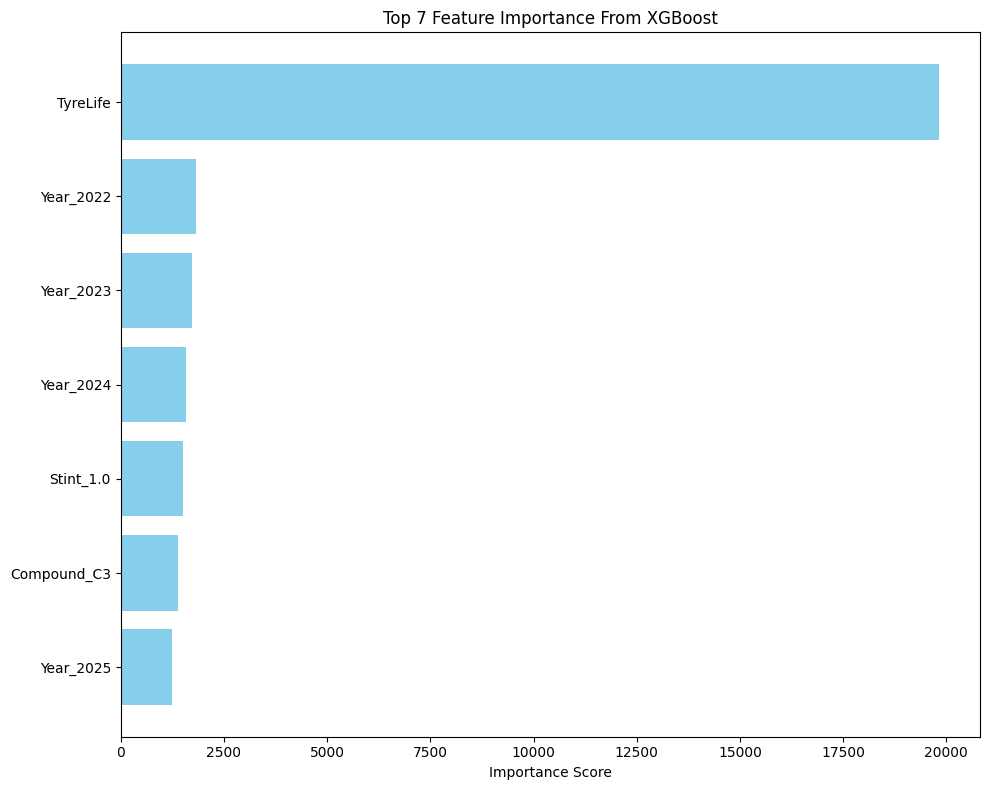

In [286]:
top_n = 7
plt.figure(figsize=(10, 8))
plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance From XGBoost')
plt.tight_layout()
plt.show()

In [287]:
from sklearn.neural_network import MLPRegressor

model_nn = Pipeline(steps=[
    ('preprocess', preprocess),
    ('regressor', MLPRegressor(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        learning_rate_init=0.05,
        max_iter=300,
        random_state=45432
        # n_jobs=4  
    ))
])

In [288]:
model_nn

,steps,"[('preprocess', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [289]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

In [290]:

y_pred = model_nn.predict(X_test)


NotFittedError: Pipeline is not fitted yet.

In [ ]:

y_pred = grid_search.best_estimator_.predict(X_test)


from sklearn.metrics import r2_score, mean_squared_error
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

R²: 0.716301441192627
RMSE: 0.05855183303356171


In [ ]:
y_pred[0]

np.float32(-0.19937979)

In [265]:
z_laps.iloc[0]
X_one = z_laps[features]
y_one = z_laps[target]
